In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("hospital (1).csv")

In [7]:
data.tail(60)

,AGE,GENDER,MARITAL_STATUS,KEY_COMPLAINTS_CODE,BODY_WEIGHT,BODY_HEIGHT,HR_PULSE,BP_HIGH,BP_LOW,RR,...,TYPE_OF_ADMSN,TOTAL_COST_TO_HOSPITAL,TOTAL_AMOUNT_BILLED_TO_THE_PATIENT,CONCESSION,ACTUAL_RECEIVABLE_AMOUNT,TOTAL_LENGTH_OF_STAY,LENGTH_OF_STAY_ICU,LENGTH_OF_STAY_WARD,IMPLANT_USED_,COST_OF_IMPLANT
188,3.00,M,UNMARRIED,other-tertalogy,13,88,110,NaN,NaN,24,...,ELECTIVE,168670.0,150000,37500,112500,11,1,10,N,0
189,2.00,M,UNMARRIED,OS-ASD,11,83,96,NaN,NaN,28,...,ELECTIVE,163914.0,150000,80000,70000,15,1,14,N,0
190,63.00,M,MARRIED,other- heart,62,172,98,130.0,70.0,20,...,ELECTIVE,241130.0,247000,0,247000,9,2,7,Y,51450
191,68.00,M,MARRIED,CAD-DVD,64,154,80,160.0,100.0,20,...,ELECTIVE,138535.0,150000,15000,135000,9,1,8,N,0
192,16.00,M,UNMARRIED,NaN,43,163,84,100.0,80.0,24,...,ELECTIVE,119348.0,106148,0,106148,9,2,7,N,0
193,63.00,M,MARRIED,CAD-TVD,54,157,76,160.0,90.0,15,...,EMERGENCY,154354.0,181063,0,181063,11,1,10,N,0
194,3.00,M,UNMARRIED,PM-VSD,13,53,88,100.0,80.0,18,...,ELECTIVE,119877.0,150000,37500,112500,7,1,6,N,0
195,1.00,F,UNMARRIED,other- heart,9,80,100,80.0,40.0,18,...,ELECTIVE,135019.0,150000,37500,112500,7,1,6,N,0
196,1.00,F,UNMARRIED,ACHD,6,72,92,100.0,40.0,24,...,ELECTIVE,176383.0,150000,70000,80000,16,2,14,N,0
197,2.00,F,UNMARRIED,other- heart,11,78,126,100.0,60.0,24,...,ELECTIVE,233522.0,150000,37500,112500,15,5,10,N,0


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   AGE                                 248 non-null    float64
 1   GENDER                              248 non-null    object 
 2   MARITAL_STATUS                      248 non-null    object 
 3   KEY_COMPLAINTS_CODE                 212 non-null    object 
 4   BODY_WEIGHT                         248 non-null    int64  
 5   BODY_HEIGHT                         248 non-null    int64  
 6   HR_PULSE                            248 non-null    int64  
 7   BP_HIGH                             225 non-null    float64
 8   BP_LOW                              225 non-null    float64
 9   RR                                  248 non-null    int64  
 10  PAST_MEDICAL_HISTORY_CODE           75 non-null     object 
 11  HB                                  246 non-n

In [686]:
data.shape

(248, 26)

In [462]:
len(data)

248

In [460]:
data.size

6448

In [636]:
data.isnull().sum()

AGE                                     0
GENDER                                  0
MARITAL_STATUS                          0
KEY_COMPLAINTS_CODE                    36
BODY_WEIGHT                             0
BODY_HEIGHT                             0
HR_PULSE                                0
BP_HIGH                                23
BP_LOW                                 23
RR                                      0
PAST_MEDICAL_HISTORY_CODE             173
HB                                      2
UREA                                   13
CREATININE                             33
MODE_OF_ARRIVAL                         0
STATE_AT_THE_TIME_OF_ARRIVAL            0
TYPE_OF_ADMSN                           0
TOTAL_COST_TO_HOSPITAL                  0
TOTAL_AMOUNT_BILLED_TO_THE_PATIENT      0
CONCESSION                              0
ACTUAL_RECEIVABLE_AMOUNT                0
TOTAL_LENGTH_OF_STAY                    0
LENGTH_OF_STAY_ICU                      0
LENGTH_OF_STAY_WARD               

In [638]:
data.isna().sum()

AGE                                     0
GENDER                                  0
MARITAL_STATUS                          0
KEY_COMPLAINTS_CODE                    36
BODY_WEIGHT                             0
BODY_HEIGHT                             0
HR_PULSE                                0
BP_HIGH                                23
BP_LOW                                 23
RR                                      0
PAST_MEDICAL_HISTORY_CODE             173
HB                                      2
UREA                                   13
CREATININE                             33
MODE_OF_ARRIVAL                         0
STATE_AT_THE_TIME_OF_ARRIVAL            0
TYPE_OF_ADMSN                           0
TOTAL_COST_TO_HOSPITAL                  0
TOTAL_AMOUNT_BILLED_TO_THE_PATIENT      0
CONCESSION                              0
ACTUAL_RECEIVABLE_AMOUNT                0
TOTAL_LENGTH_OF_STAY                    0
LENGTH_OF_STAY_ICU                      0
LENGTH_OF_STAY_WARD               

In [468]:
data["PAST_MEDICAL_HISTORY_CODE"].value_counts()

PAST_MEDICAL_HISTORY_CODE
hypertension1    20
other            15
hypertension2    13
Diabetes1        10
Diabetes2         9
hypertension3     5
Hypertension1     3
Name: count, dtype: int64

In [470]:
data["AGE"].dtype

dtype('float64')

In [740]:
data["AGE"]=data["AGE"].astype(int)

In [742]:
data["AGE"].dtype

dtype('int32')

In [744]:
data["AGE"].mean().round(2)

47.85

In [11]:
data["PAST_MEDICAL_HISTORY_CODE"]

0                NaN
1                NaN
2          Diabetes2
3      hypertension1
4          Diabetes2
           ...      
243              NaN
244            other
245    hypertension1
246              NaN
247              NaN
Name: PAST_MEDICAL_HISTORY_CODE, Length: 248, dtype: object

In [13]:
Age_Bins=[0,18,35,60,100]
Age_label=["0-18","19-35","36-60","60+"]
data["Age_Group"]=pd.cut(
    data["AGE"],
    bins=Age_Bins,
    labels=Age_label,
    right=False
)

In [15]:
data["Age_Group"].value_counts()

Age_Group
0-18     131
36-60     54
60+       47
19-35     16
Name: count, dtype: int64

In [17]:
age_count=data["Age_Group"].value_counts()
age_count

Age_Group
0-18     131
36-60     54
60+       47
19-35     16
Name: count, dtype: int64

In [19]:
gender_by_medhist= pd.crosstab (data["GENDER"],data["PAST_MEDICAL_HISTORY_CODE"])
gender_by_medhist

PAST_MEDICAL_HISTORY_CODE,Diabetes1,Diabetes2,Hypertension1,hypertension1,hypertension2,hypertension3,other
GENDER,,,,,,,
F,2,1,0,2,4,2,4
M,8,8,3,18,9,3,11


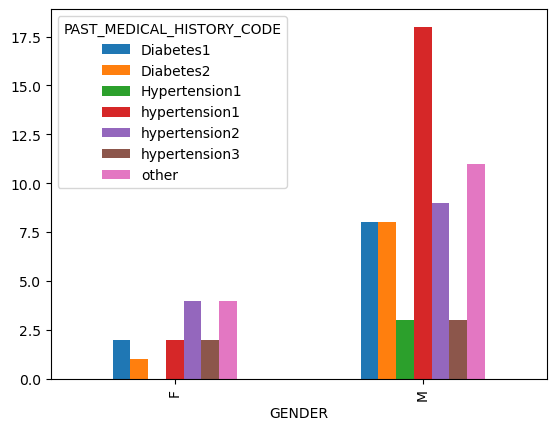

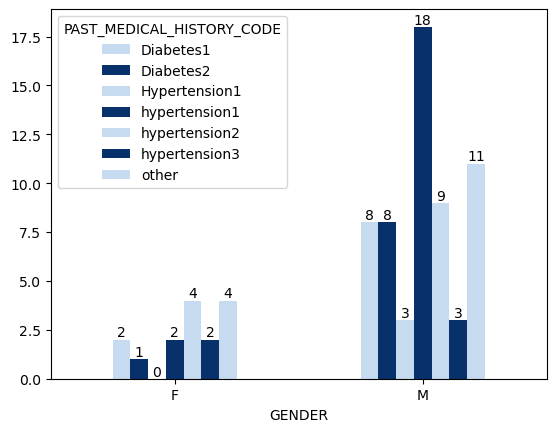

In [21]:
import matplotlib.cm as cm
ax=gender_by_medhist.plot(kind="bar")
values=gender_by_medhist.sum(axis=1)
colors=cm.Blues(values/values.max())
ax=gender_by_medhist.plot(kind="bar",color=colors)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=360)
plt.show()

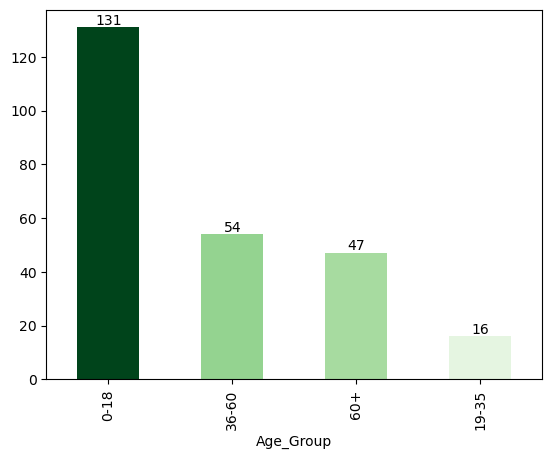

In [25]:
values=age_count.values
colors = cm.Greens(values / values.max())
ax=age_count.plot(kind="bar",color=colors)
for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   AGE                                 248 non-null    float64 
 1   GENDER                              248 non-null    object  
 2   MARITAL_STATUS                      248 non-null    object  
 3   KEY_COMPLAINTS_CODE                 212 non-null    object  
 4   BODY_WEIGHT                         248 non-null    int64   
 5   BODY_HEIGHT                         248 non-null    int64   
 6   HR_PULSE                            248 non-null    int64   
 7   BP_HIGH                             225 non-null    float64 
 8   BP_LOW                              225 non-null    float64 
 9   RR                                  248 non-null    int64   
 10  PAST_MEDICAL_HISTORY_CODE           75 non-null     object  
 11  HB                              

In [29]:

data = data[(data["BODY_HEIGHT"] >= 120) & (data["BODY_HEIGHT"] <= 210)]


data = data[(data["BODY_WEIGHT"] >= 30) & (data["BODY_WEIGHT"] <= 250)]


data["BMI"] = data["BODY_WEIGHT"] / ((data["BODY_HEIGHT"] / 100) ** 2)


In [31]:
data["BMI"].describe()

count    136.000000
mean      22.017080
std        4.522366
min       12.121212
25%       18.695398
50%       22.071078
75%       24.804819
max       33.710093
Name: BMI, dtype: float64

In [80]:
data

,AGE,GENDER,MARITAL_STATUS,KEY_COMPLAINTS_CODE,BODY_WEIGHT,BODY_HEIGHT,HR_PULSE,BP_HIGH,BP_LOW,RR,...,TOTAL_AMOUNT_BILLED_TO_THE_PATIENT,CONCESSION,ACTUAL_RECEIVABLE_AMOUNT,TOTAL_LENGTH_OF_STAY,LENGTH_OF_STAY_ICU,LENGTH_OF_STAY_WARD,IMPLANT_USED_,COST_OF_IMPLANT,Age_Group,BMI
0,58.0,M,MARRIED,other- heart,49,160,118,100.0,80.0,32,...,474901,0,474901,25,12,13,Y,38000,36-60,19.140625
1,59.0,M,MARRIED,CAD-DVD,41,155,78,70.0,50.0,28,...,944819,96422,848397,41,20,21,Y,39690,36-60,17.065557
2,82.0,M,MARRIED,CAD-TVD,47,164,100,110.0,80.0,20,...,390000,30000,360000,18,9,9,N,0,60+,17.474717
3,46.0,M,MARRIED,CAD-DVD,80,173,122,110.0,80.0,24,...,324910,0,324910,14,13,1,Y,89450,36-60,26.729927
4,60.0,M,MARRIED,CAD-DVD,58,175,72,180.0,100.0,18,...,254673,10000,244673,24,12,12,N,0,60+,18.938776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243,51.0,M,MARRIED,other- heart,69,176,62,130.0,90.0,24,...,197000,0,197000,10,3,7,Y,35000,36-60,22.275310
244,58.0,M,MARRIED,CAD-TVD,57,159,58,100.0,70.0,24,...,220000,0,220000,11,2,9,Y,26000,36-60,22.546576
245,44.0,M,MARRIED,CAD-TVD,58,159,68,150.0,90.0,24,...,150000,10000,140000,13,5,8,N,0,36-60,22.942130
246,60.0,M,MARRIED,other- heart,65,165,98,100.0,60.0,17,...,229920,10000,219920,9,6,3,N,0,60+,23.875115


In [82]:
data["TOTAL_AMOUNT_BILLED_TO_THE_PATIENT"].max()

944819

In [84]:
data["TOTAL_AMOUNT_BILLED_TO_THE_PATIENT"].min()

47700

In [56]:
gender_by_los=data.groupby("GENDER")["TOTAL_LENGTH_OF_STAY"].mean()

In [60]:
gender_by_los.round(2)

GENDER
F    10.64
M    12.89
Name: TOTAL_LENGTH_OF_STAY, dtype: float64

In [70]:
gender_by_bill=data.groupby("GENDER")["TOTAL_AMOUNT_BILLED_TO_THE_PATIENT"].mean()

In [74]:
gender_by_bill.round(2)

GENDER
F    168817.32
M    246730.78
Name: TOTAL_AMOUNT_BILLED_TO_THE_PATIENT, dtype: float64

In [86]:
gender_by_status=pd.crosstab(data["GENDER"],data["MARITAL_STATUS"])

In [88]:
gender_by_status

MARITAL_STATUS,MARRIED,UNMARRIED
GENDER,,
F,26,18
M,81,11


In [90]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
243    False
244    False
245    False
246    False
247    False
Length: 136, dtype: bool

In [94]:
gender_by_implant=pd.crosstab(data["GENDER"],data["IMPLANT_USED_"])
gender_by_implant

IMPLANT_USED_,N,Y
GENDER,,
F,26,18
M,66,26


In [96]:
data["HB"].describe()

count    135.000000
mean      12.688889
std        2.309832
min        7.000000
25%       11.000000
50%       13.000000
75%       14.000000
max       23.000000
Name: HB, dtype: float64

In [98]:
data["HB"].max()

23.0

In [100]:
data["HB"].min()

7.0

In [102]:
hb_male_adult= data[(data["HB"].between(13.8,17.2))&(data["GENDER"]=="M")]

In [112]:
len(hb_male_adult)

37

In [116]:
hb_Female_adult= data[(data["HB"].between(12.1,15.1))&(data["GENDER"]=="F")]
hb_Female_adult

,AGE,GENDER,MARITAL_STATUS,KEY_COMPLAINTS_CODE,BODY_WEIGHT,BODY_HEIGHT,HR_PULSE,BP_HIGH,BP_LOW,RR,...,TOTAL_AMOUNT_BILLED_TO_THE_PATIENT,CONCESSION,ACTUAL_RECEIVABLE_AMOUNT,TOTAL_LENGTH_OF_STAY,LENGTH_OF_STAY_ICU,LENGTH_OF_STAY_WARD,IMPLANT_USED_,COST_OF_IMPLANT,Age_Group,BMI
11,45.0,F,MARRIED,other- heart,50,151,60,110.0,60.0,19,...,194000,10000,184000,27,22,5,Y,20900,36-60,21.928863
14,68.0,F,UNMARRIED,CAD-DVD,51,123,66,120.0,80.0,20,...,161250,0,161250,16,16,0,N,0,60+,33.710093
46,39.0,F,MARRIED,NaN,77,153,86,130.0,80.0,26,...,127350,0,127350,8,2,6,N,0,36-60,32.893332
63,12.0,F,UNMARRIED,other- heart,35,140,102,100.0,70.0,26,...,163940,0,163940,9,1,8,N,0,0-18,17.857143
66,33.0,F,MARRIED,NaN,63,147,68,120.0,80.0,24,...,106156,0,106156,8,1,7,N,0,19-35,29.154519
76,33.0,F,MARRIED,NaN,63,147,68,120.0,80.0,24,...,106156,0,106156,8,1,7,N,0,19-35,29.154519
93,65.0,F,MARRIED,ACHD,43,155,101,130.0,90.0,24,...,165089,0,165089,8,2,6,Y,30870,60+,17.898023
105,45.0,F,MARRIED,other- heart,41,152,88,110.0,70.0,20,...,116591,0,116591,7,3,4,N,0,36-60,17.745845
107,41.0,F,MARRIED,RHD,64,162,62,110.0,70.0,22,...,229537,0,229537,10,1,9,Y,82320,36-60,24.386526
112,44.0,F,MARRIED,ACHD,60,157,86,150.0,80.0,22,...,159000,20000,139000,7,2,5,N,0,36-60,24.341758


In [122]:
hb_Female_Pregnant= data[(data["HB"]>=11)&(data["GENDER"]=="F")]
hb_Female_Pregnant

,AGE,GENDER,MARITAL_STATUS,KEY_COMPLAINTS_CODE,BODY_WEIGHT,BODY_HEIGHT,HR_PULSE,BP_HIGH,BP_LOW,RR,...,TOTAL_AMOUNT_BILLED_TO_THE_PATIENT,CONCESSION,ACTUAL_RECEIVABLE_AMOUNT,TOTAL_LENGTH_OF_STAY,LENGTH_OF_STAY_ICU,LENGTH_OF_STAY_WARD,IMPLANT_USED_,COST_OF_IMPLANT,Age_Group,BMI
11,45.0,F,MARRIED,other- heart,50,151,60,110.0,60.0,19,...,194000,10000,184000,27,22,5,Y,20900,36-60,21.928863
14,68.0,F,UNMARRIED,CAD-DVD,51,123,66,120.0,80.0,20,...,161250,0,161250,16,16,0,N,0,60+,33.710093
17,59.0,F,MARRIED,RHD,47,150,60,130.0,90.0,24,...,89050,0,89050,17,5,12,Y,20800,36-60,20.888889
20,54.0,F,MARRIED,CAD-DVD,51,147,110,100.0,70.0,26,...,250001,0,250001,16,10,6,N,0,36-60,23.601277
37,63.0,F,MARRIED,other- heart,59,162,76,150.0,80.0,15,...,346847,600,346247,16,5,11,N,0,60+,22.481329
46,39.0,F,MARRIED,NaN,77,153,86,130.0,80.0,26,...,127350,0,127350,8,2,6,N,0,36-60,32.893332
60,14.0,F,UNMARRIED,NaN,49,149,111,100.0,80.0,26,...,150000,37500,112500,7,3,4,N,0,0-18,22.071078
63,12.0,F,UNMARRIED,other- heart,35,140,102,100.0,70.0,26,...,163940,0,163940,9,1,8,N,0,0-18,17.857143
66,33.0,F,MARRIED,NaN,63,147,68,120.0,80.0,24,...,106156,0,106156,8,1,7,N,0,19-35,29.154519
67,21.0,F,UNMARRIED,NaN,51,153,74,110.0,70.0,24,...,47700,0,47700,6,1,5,N,0,19-35,21.786492


In [130]:
hb_children= data[(data["HB"].between(11.0,15.5))&(data["AGE"].between(1.0,12.0))]
hb_children

,AGE,GENDER,MARITAL_STATUS,KEY_COMPLAINTS_CODE,BODY_WEIGHT,BODY_HEIGHT,HR_PULSE,BP_HIGH,BP_LOW,RR,...,TOTAL_AMOUNT_BILLED_TO_THE_PATIENT,CONCESSION,ACTUAL_RECEIVABLE_AMOUNT,TOTAL_LENGTH_OF_STAY,LENGTH_OF_STAY_ICU,LENGTH_OF_STAY_WARD,IMPLANT_USED_,COST_OF_IMPLANT,Age_Group,BMI
63,12.0,F,UNMARRIED,other- heart,35,140,102,100.0,70.0,26,...,163940,0,163940,9,1,8,N,0,0-18,17.857143
131,12.0,F,UNMARRIED,ACHD,41,154,84,NaN,NaN,20,...,150000,37500,112500,7,1,6,N,0,0-18,17.287907
185,11.0,M,UNMARRIED,OS-ASD,33,165,88,110.0,80.0,24,...,150000,37500,112500,8,3,5,N,0,0-18,12.121212


In [132]:
bins=[0,5,6.5,7.9,8.0,10.0]
labels=["critical crisis","life_threatening","severe","moderate","mild"]
data["Low_HB_Anemia"]=pd.cut(
    data["HB"],
    bins=bins,
    labels=labels,
    right=True
)

In [136]:
data["Low_HB_Anemia"].value_counts()

Low_HB_Anemia
mild                19
moderate             4
severe               1
critical crisis      0
life_threatening     0
Name: count, dtype: int64

In [150]:
bins=[0,16.5,18.1,20,np.inf]
labels=["Br_High","High","very_high","Extreme"]
data["High_HB_Polycythemia"]=pd.cut(
    data["HB"],
    bins=bins,
    labels=labels,
    right=True
)

In [152]:
data["High_HB_Polycythemia"].value_counts()

High_HB_Polycythemia
Br_High      132
Extreme        2
High           1
very_high      0
Name: count, dtype: int64

In [146]:
data["CREATININE"].describe()

count    120.000000
mean       1.007500
std        0.586854
min        0.300000
25%        0.700000
50%        0.950000
75%        1.100000
max        5.200000
Name: CREATININE, dtype: float64

In [156]:
bins=[0,1.3,3.0,5.0,np.inf]
labels=["Mild_high","Moderate","Severe","Critical"]
data["Creatinine_group"]=pd.cut(
    data["CREATININE"],
    bins=bins,
    labels=labels,
    right=True
)

In [166]:
creatine_group=data["Creatinine_group"].value_counts()
creatine_group

Creatinine_group
Mild_high    104
Moderate      15
Critical       1
Severe         0
Name: count, dtype: int64

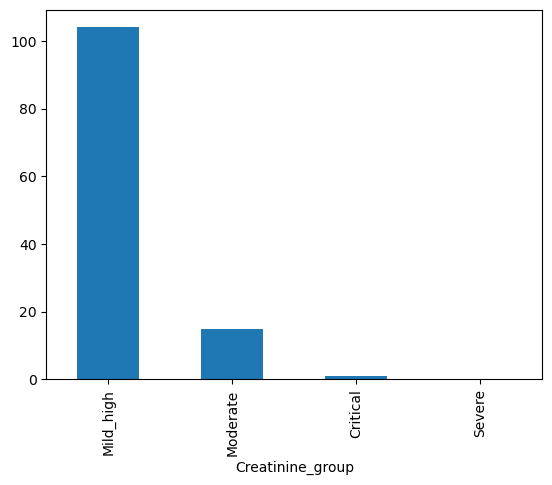

In [164]:
creatine_group.plot(kind="bar")
plt.show()

In [ ]:
username: Kamatam PAb